In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import re
import lightgbm as lgb
from scipy.special import softmax
from sklearn.metrics import f1_score, classification_report
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

## Import Data

In [ ]:
train_df = pd.read_csv('/data/processed/processed_train.csv')
test_df = pd.read_csv('/data/processed/processed_test.csv')

## Feature Encoding

In [ ]:
# select the Id/index
train_ids = train_df['ID']
# select the target
y = train_df['Target']
#select features
X = train_df.drop(columns=['ID', 'Target'])
X_test=test_df.drop(columns=['ID'])

# Define categorical features
cat_cols =['country', 'attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax', 
           'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 
           'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'offers_credit_to_customers',
           'attitude_satisfied_with_achievement', 'has_credit_card', 'keeps_financial_records',
           'perception_insurance_companies_dont_insure_businesses_like_yours', 'perception_insurance_important',
           'has_insurance', 'covid_essential_service', 'attitude_more_successful_next_year', 'problem_sourcing_money',
           'marketing_word_of_mouth', 'has_loan_account', 'has_internet_banking', 'has_debit_card',
           'future_risk_theft_stock', 'motivation_make_more_money',
           'uses_friends_family_savings', 'uses_informal_lender','country_x_cashflow','country_x_insurance'
          ]
# Define numerical features
num_cols= [col for col in X.columns if col not in cat_cols]

In [ ]:
# drop='first' is used to avoid the "dummy variable trap" (multicollinearity)
# sparse_output=False makes the result a standard array (easier to read)
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

################################################################################################################
# Create the full preprocessor
# We apply the cat_pipe ONLY to categorical columns. 
# Numerical columns can be kept 'passthrough' for now
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, cat_cols),
        ('num', 'passthrough', num_cols) # Keep numerical data as-is for now
    ],
    remainder='drop' # This drops the ID column automatically
)

# Transform data
X_processed = preprocessor.fit_transform(X)
X_test_processed=preprocessor.transform(X_test)

# Convert back to a DataFrame for readability
encoded_feature_names = preprocessor.get_feature_names_out()
X_final = pd.DataFrame(X_processed, columns=encoded_feature_names)
X_test_final = pd.DataFrame(X_test_processed, columns=encoded_feature_names)

## Dropped Columns that are not giving any useful information

In [5]:
X_final = X_final.drop(["cat__attitude_more_successful_next_year_don't know or n/a",
                        "cat__uses_friends_family_savings_don't know (do not show)",
                        "cat__uses_informal_lender_don't know (do not show)",
                        "cat__perception_insurance_important_don?t know / doesn?t apply",
                        "cat__perception_insurance_important_don't know",
                        "cat__has_internet_banking_don't know (do not show)",
                        "cat__has_mobile_money_used to have but don't have now",
                        "cat__compliance_income_tax_refused",
                        "cat__has_loan_account_don't know (do not show)"], axis=1)
X_test_processed= X_test_final.drop(["cat__attitude_more_successful_next_year_don't know or n/a",
                        "cat__uses_friends_family_savings_don't know (do not show)",
                        "cat__uses_informal_lender_don't know (do not show)",
                        "cat__perception_insurance_important_don?t know / doesn?t apply",
                        "cat__perception_insurance_important_don't know",
                        "cat__has_internet_banking_don't know (do not show)",
                        "cat__has_mobile_money_used to have but don't have now",
                        "cat__compliance_income_tax_refused",
                        "cat__has_loan_account_don't know (do not show)"], axis=1)

## More Features

In [6]:
X_final["financial_stress"] = (
    X_final["num__log_expenses"] / (X_final["num__log_income"] + 1)
) + (
    X_final["cat__problem_sourcing_money_yes"] * 1.5
) + (
    X_final["cat__current_problem_cash_flow_yes"] * 2
)

X_test_processed["financial_stress"] = (
    X_test_processed["num__log_expenses"] / (X_test_processed["num__log_income"] + 1)
) + (
    X_test_processed["cat__problem_sourcing_money_yes"] * 1.5
) + (
    X_test_processed["cat__current_problem_cash_flow_yes"] * 2
)

## Split For Training and Testing

In [7]:
# 2. Perform the Stratified Split
# 'stratify=y' ensures the 4.9% ratio is maintained in both sets
# 'random_state=42' makes your results reproducible every time you run it
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Keep track of IDs for later
# We need to split these too so we can map predictions back to customers
train_ids = train_df['ID']
test_ids = test_df['ID']

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 7694
Testing set size: 1924


In [8]:
## Define mapping
label_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

# 2. Apply the mapping to your target arrays
y_train_encoded = y_train.map(label_mapping)
y_test_encoded = y_test.map(label_mapping)

In [9]:
X_train_light=X_train.copy()
X_test_light=X_test.copy()

In [10]:
X_train_light.columns = [
    re.sub('[^0-9a-zA-Z]+', '_', col) for col in X_train.columns
]
X_test_light.columns = X_train_light.columns

In [11]:
X_test_processed.columns = [
    re.sub('[^0-9a-zA-Z]+', '_', col) for col in X_test_processed.columns
]
X_test_processed.columns = X_test_processed.columns

## Model 1: XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=522,
    learning_rate=0.07104274945954676,
    max_depth=5,
    reg_alpha=1.0,  # L1 regularization
    reg_lambda=1.0, # L2 regularization
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    subsample=0.8819196018669633, 
    colsample_bytree=0.6425045795096875,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    enable_categorical=True
)

# Fit the pipeline

xgb_model.fit(X_train_light, y_train_encoded)

19.46276595744681


C:\Users\aakri\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [21:34:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=0.6425045795096875,
              device=None, early_stopping_rounds=None, enable_categorical=True,
              eval_metric='mlogloss', feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.07104274945954676,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=522, n_jobs=-1, num_class=3, ...)

In [14]:
xgmb_pred = xgb_model.predict_proba(X_test_light)

## Model 2: Catboost

In [15]:
cat = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    iterations=1500,
    random_seed=42,
    verbose=200
)

cat.fit(
    X_train_light, y_train_encoded,
    eval_set=(X_test_light, y_test_encoded),
    use_best_model=True
)

cat_pred = cat.predict_proba(X_test_light)

0:	learn: 0.8010684	test: 0.7862371	best: 0.7862371 (0)	total: 162ms	remaining: 4m 2s
200:	learn: 0.8820803	test: 0.8688275	best: 0.8688275 (192)	total: 4.17s	remaining: 26.9s
400:	learn: 0.9010679	test: 0.8685326	best: 0.8707888 (246)	total: 8.23s	remaining: 22.6s
600:	learn: 0.9174011	test: 0.8671140	best: 0.8707888 (246)	total: 12.5s	remaining: 18.7s
800:	learn: 0.9304945	test: 0.8683690	best: 0.8707888 (246)	total: 16.5s	remaining: 14.4s
1000:	learn: 0.9426579	test: 0.8698579	best: 0.8708322 (934)	total: 20.4s	remaining: 10.2s
1200:	learn: 0.9507179	test: 0.8661394	best: 0.8708322 (934)	total: 24.2s	remaining: 6.04s
1400:	learn: 0.9573083	test: 0.8677832	best: 0.8708322 (934)	total: 27.9s	remaining: 1.97s
1499:	learn: 0.9608192	test: 0.8668118	best: 0.8708322 (934)	total: 29.8s	remaining: 0us

bestTest = 0.870832225
bestIteration = 934

Shrink model to first 935 iterations.


## Model 3: Light GBM

In [17]:
lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    learning_rate=0.09426419007154008,
    max_depth=-1,
    n_estimators=1200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    lambda_l1= 0.0004682657442436951,
    num_leaves= 52,
    feature_fraction= 0.5542747564886497,
    bagging_fraction= 0.607189665005347
)

lgbm.fit(X_train_light, y_train_encoded)
lgbm_pred = lgbm.predict_proba(X_test_light)

[LightGBM] [Warning] feature_fraction is set=0.5542747564886497, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.5542747564886497
[LightGBM] [Warning] lambda_l1 is set=0.0004682657442436951, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0004682657442436951
[LightGBM] [Warning] bagging_fraction is set=0.607189665005347, subsample=0.8 will be ignored. Current value: bagging_fraction=0.607189665005347
[LightGBM] [Warning] feature_fraction is set=0.5542747564886497, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.5542747564886497
[LightGBM] [Warning] lambda_l1 is set=0.0004682657442436951, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0004682657442436951
[LightGBM] [Warning] bagging_fraction is set=0.607189665005347, subsample=0.8 will be ignored. Current value: bagging_fraction=0.607189665005347
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001904 seconds.
You can set `force_r

## Score- F1

In [19]:
combined_probs = (0.2*xgmb_pred + 0.7*cat_pred + 0.1*lgbm_pred) 

final_preds = np.argmax(combined_probs, axis=1)


# Use 'macro' to see how you're doing across all three health levels
combined_f1 = f1_score(y_test_encoded, final_preds, average='macro')

print(f"Multiclass Combined F1: {combined_f1:.4f}")
print(classification_report(y_test_encoded, final_preds))

Multiclass Combined F1: 0.8115
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1256
           1       0.86      0.71      0.78       574
           2       0.92      0.61      0.73        94

    accuracy                           0.88      1924
   macro avg       0.89      0.76      0.81      1924
weighted avg       0.88      0.88      0.87      1924



## Feature Importance Graph

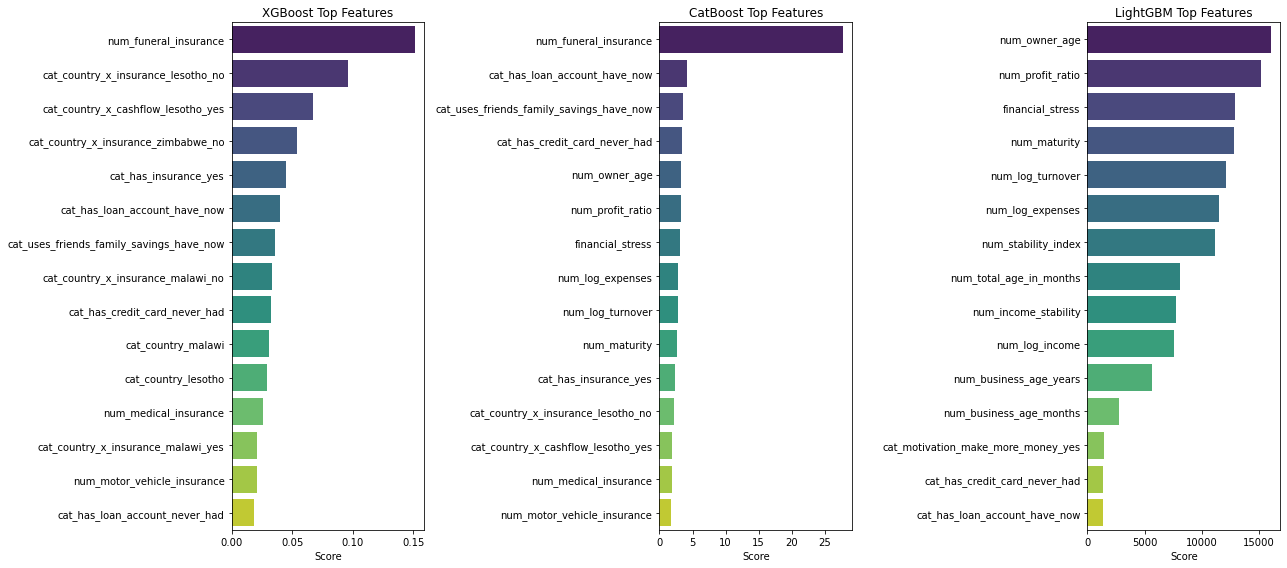

In [48]:
def plot_importance(models, model_names, feature_names, top_n=15):
    fig, axes = plt.subplots(1, len(models), figsize=(18, 8))
    
    for i, model in enumerate(models):
        # Extract importance
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
        else:
            # Fallback for models that might store it differently
            importances = model.get_feature_importances() 
            
        data = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False).head(top_n)
        
        sns.barplot(x='Importance', y='Feature', data=data, ax=axes[i], palette='viridis')
        axes[i].set_title(f'{model_names[i]} Top Features')
        axes[i].set_xlabel('Score')
        axes[i].set_ylabel('')

    plt.tight_layout()
    plt.show()

# Usage (Replace with your actual model variables and column list)
plot_importance(
    models=[xgb_model, cat, lgbm],
    model_names=['XGBoost', 'CatBoost', 'LightGBM'],
    feature_names=X_train_light.columns
)

## Combining Scores

In [20]:
y_probs_xgb = xgb_model.predict_proba(X_test_processed)
y_probs_cat = cat.predict_proba(X_test_processed)
y_probs_lgm = lgbm.predict_proba(X_test_processed)

[LightGBM] [Warning] feature_fraction is set=0.5542747564886497, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.5542747564886497
[LightGBM] [Warning] lambda_l1 is set=0.0004682657442436951, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0004682657442436951
[LightGBM] [Warning] bagging_fraction is set=0.607189665005347, subsample=0.8 will be ignored. Current value: bagging_fraction=0.607189665005347


In [31]:
final_preds_cal=0.55 * y_probs_cat + 0.35 * y_probs_xgb + 0.1 * y_probs_lgm
final_preds_cal

array([[9.29877026e-01, 6.32573033e-02, 6.86564486e-03],
       [9.24768146e-01, 7.44760043e-02, 7.55851206e-04],
       [9.71164693e-01, 2.70784634e-02, 1.75684929e-03],
       ...,
       [3.84272124e-03, 8.62389892e-01, 1.33767399e-01],
       [3.04678131e-03, 8.94266028e-01, 1.02687198e-01],
       [9.57484461e-01, 3.94224467e-02, 3.09309190e-03]])

In [32]:
final_preds_cal = softmax(final_preds_cal * 1.2, axis=1)

In [33]:
final_labels = np.argmax(final_preds_cal, axis=1)

In [34]:
# The original mapping
label_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

# Create the inverse mapping
reverse_mapping = {v: k for k, v in label_mapping.items()}

# Convert predictions
final_encoded = [reverse_mapping[pred] for pred in final_labels]

In [35]:
submission  = pd.DataFrame({
    'ID':test_ids,
    'Target':final_encoded})
submission.head()

,ID,Target
0,ID_5EGLKX,Low
1,ID_4AI7RE,Low
2,ID_V9OB3M,Low
3,ID_6OI9DI,Low
4,ID_H2TN8B,Low


In [36]:
submission['Target'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [37]:
submission['Target'].value_counts()

Low       1746
Medium     564
High        95
Name: Target, dtype: int64

In [43]:
submission.to_csv('submission.csv', index=False)
print("\nSuccess!  is ready for upload.")


Success!  is ready for upload.


## Hyper Parameter Selection- XGBoost

In [31]:
def objective(trial):
    # Define the hyperparameter search space
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }
    
    model = XGBClassifier(**param, random_state=42)
    model.fit(X_train_light, y_train_encoded)
    
    # Evaluate using the F1 score (better for imbalanced classes than Accuracy)
    preds = model.predict(X_test_light)
    return f1_score(y_test_encoded, preds, average='weighted')

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Best trial: {study.best_params}")

[I 2026-03-24 21:28:21,328] A new study created in memory with name: no-name-5a530a5a-f075-4a2e-9b91-87bc54de6642
[I 2026-03-24 21:28:23,783] Trial 0 finished with value: 0.867212900617593 and parameters: {'n_estimators': 144, 'max_depth': 9, 'learning_rate': 0.03732497061444247, 'subsample': 0.6013768652430164, 'colsample_bytree': 0.6672460972084862}. Best is trial 0 with value: 0.867212900617593.
[I 2026-03-24 21:28:25,217] Trial 1 finished with value: 0.8703154935283968 and parameters: {'n_estimators': 186, 'max_depth': 3, 'learning_rate': 0.09859254612771587, 'subsample': 0.6418805551999889, 'colsample_bytree': 0.6534067442126816}. Best is trial 1 with value: 0.8703154935283968.
[I 2026-03-24 21:28:33,956] Trial 2 finished with value: 0.8676212053671061 and parameters: {'n_estimators': 605, 'max_depth': 8, 'learning_rate': 0.09837076389008145, 'subsample': 0.6828284066096515, 'colsample_bytree': 0.5999119193413734}. Best is trial 1 with value: 0.8703154935283968.
[I 2026-03-24 21:2

Best trial: {'n_estimators': 522, 'max_depth': 5, 'learning_rate': 0.07104274945954676, 'subsample': 0.8819196018669633, 'colsample_bytree': 0.6425045795096875}


## Hyper Parameter Selection- CatBoost

In [31]:
def objective_cat(trial):
    param = {
        "objective": "MultiClass",
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 4, 10), # Reduced from 12 to 10
        "boosting_type": trial.suggest_categorical("boosting_type", ["Plain"]), # 'Plain' is safer for RAM
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "iterations": 1000,
        "used_ram_limit": "4gb", # Limits RAM usage to 4GB
        "eval_metric": "TotalF1",
        "random_seed": 42,
    }

    model = CatBoostClassifier(**param, silent=True)
    model.fit(X_train_light, y_train_encoded, early_stopping_rounds=50)
    
    preds = model.predict(X_test_light)
    return f1_score(y_test_encoded, preds, average='macro')

study = optuna.create_study(direction='maximize')
study.optimize(objective_cat, n_trials=50)

print(f"Best trial: {study.best_params}")

[I 2026-03-24 16:06:41,223] A new study created in memory with name: no-name-fd10e2e6-0ed0-4b8f-bfdd-73d1bf37efec
[I 2026-03-24 16:06:50,000] Trial 0 finished with value: 0.8064637826636313 and parameters: {'colsample_bylevel': 0.0913224149634543, 'depth': 6, 'boosting_type': 'Plain', 'bootstrap_type': 'MVS', 'learning_rate': 0.09091152279235012}. Best is trial 0 with value: 0.8064637826636313.
[I 2026-03-24 16:06:54,902] Trial 1 finished with value: 0.45010693817460123 and parameters: {'colsample_bylevel': 0.05852710568523618, 'depth': 4, 'boosting_type': 'Plain', 'bootstrap_type': 'Bayesian', 'learning_rate': 0.0010123654240510942}. Best is trial 0 with value: 0.8064637826636313.
[I 2026-03-24 16:07:04,725] Trial 2 finished with value: 0.744056741823966 and parameters: {'colsample_bylevel': 0.09016558188065538, 'depth': 6, 'boosting_type': 'Plain', 'bootstrap_type': 'Bernoulli', 'learning_rate': 0.003969387320791562}. Best is trial 0 with value: 0.8064637826636313.
[I 2026-03-24 16:0

Best trial: {'colsample_bylevel': 0.09842126273062646, 'depth': 7, 'boosting_type': 'Plain', 'bootstrap_type': 'MVS', 'learning_rate': 0.06084207142878157}


## Hyper Parameter Selection- LightGBM

In [32]:
def objective_lgb(trial):
    param = {
        "objective": "multiclass",
        "num_class": 3,
        "metric": "multi_logloss",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 2, 256),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
    }

    model = lgb.LGBMClassifier(**param)
    model.fit(X_train_light, y_train_encoded,eval_set=[(X_test_light, y_test_encoded)],
              eval_metric="multi_logloss",callbacks=[lgb.early_stopping(50)])
    
    preds = model.predict(X_test_light)
    return f1_score(y_test_encoded, preds, average='macro')

study = optuna.create_study(direction='maximize')
study.optimize(objective_lgb, n_trials=50)
print(f"Best trial: {study.best_params}")

[I 2026-03-24 21:32:20,339] A new study created in memory with name: no-name-6f12585a-aa60-481d-b9ca-08df09c9aa73


Training until validation scores don't improve for 50 rounds


[I 2026-03-24 21:32:20,903] Trial 0 finished with value: 0.7718821270745052 and parameters: {'lambda_l1': 0.6310573046856787, 'num_leaves': 6, 'feature_fraction': 0.5706049879379315, 'bagging_fraction': 0.6956137187983353, 'learning_rate': 0.02649786631775638}. Best is trial 0 with value: 0.7718821270745052.


Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.389396
Training until validation scores don't improve for 50 rounds


[I 2026-03-24 21:32:22,452] Trial 1 finished with value: 0.7921798327850035 and parameters: {'lambda_l1': 0.00014998934502804805, 'num_leaves': 55, 'feature_fraction': 0.859308896777722, 'bagging_fraction': 0.6702528139312003, 'learning_rate': 0.018196796566683104}. Best is trial 1 with value: 0.7921798327850035.


...

Did not meet early stopping. Best iteration is:
[53]	valid_0's multi_logloss: 0.319816
Training until validation scores don't improve for 50 rounds


[I 2026-03-24 21:33:22,850] Trial 48 finished with value: 0.8175830489777546 and parameters: {'lambda_l1': 0.028242565347591283, 'num_leaves': 47, 'feature_fraction': 0.6104027569149801, 'bagging_fraction': 0.6709578559797761, 'learning_rate': 0.04937379240004273}. Best is trial 38 with value: 0.8180218146189248.


Did not meet early stopping. Best iteration is:
[99]	valid_0's multi_logloss: 0.317687
Training until validation scores don't improve for 50 rounds


[I 2026-03-24 21:33:24,994] Trial 49 finished with value: 0.8077246581048861 and parameters: {'lambda_l1': 0.0021856797515998018, 'num_leaves': 110, 'feature_fraction': 0.7926887724481865, 'bagging_fraction': 0.7730711277917193, 'learning_rate': 0.049824530187914884}. Best is trial 38 with value: 0.8180218146189248.


Did not meet early stopping. Best iteration is:
[70]	valid_0's multi_logloss: 0.322427
Best trial: {'lambda_l1': 0.0004682657442436951, 'num_leaves': 52, 'feature_fraction': 0.5542747564886497, 'bagging_fraction': 0.607189665005347, 'learning_rate': 0.09426419007154008}


## Finding Weights

In [29]:
# Define your best-tuned models
estimators = [
    ('xgb', xgb_model),
    ('cat', cat),
    ('lgbm', lgbm)
]

# The Meta-Model finds the weights for you
stack_model = StackingClassifier(
    estimators=estimators, 
    final_estimator=LogisticRegression(),
    cv=5 # Cross-validation to prevent overfitting
)

stack_model.fit(X_train_light, y_train_encoded)

C:\Users\aakri\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [21:36:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)


0:	learn: 0.8010684	total: 41.2ms	remaining: 1m 1s
200:	learn: 0.8820803	total: 6.44s	remaining: 41.6s
400:	learn: 0.9010679	total: 12.7s	remaining: 34.7s
600:	learn: 0.9174011	total: 17.7s	remaining: 26.5s
800:	learn: 0.9304945	total: 22.3s	remaining: 19.5s
1000:	learn: 0.9426579	total: 27s	remaining: 13.4s
1200:	learn: 0.9507179	total: 31.5s	remaining: 7.85s
1400:	learn: 0.9573083	total: 35s	remaining: 2.47s
1499:	learn: 0.9608192	total: 36.7s	remaining: 0us
[LightGBM] [Warning] feature_fraction is set=0.5542747564886497, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.5542747564886497
[LightGBM] [Warning] lambda_l1 is set=0.0004682657442436951, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0004682657442436951
[LightGBM] [Warning] bagging_fraction is set=0.607189665005347, subsample=0.8 will be ignored. Current value: bagging_fraction=0.607189665005347
[LightGBM] [Warning] feature_fraction is set=0.5542747564886497, colsample_bytree=0.8 will be ign

C:\Users\aakri\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [21:37:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\aakri\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [21:37:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\aakri\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [21:37:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\aakri\anaconda3\lib\site-packages\xgboost\core.py

0:	learn: 0.8294853	total: 17.5ms	remaining: 26.2s
200:	learn: 0.8798262	total: 4.31s	remaining: 27.8s
400:	learn: 0.9018600	total: 9.52s	remaining: 26.1s
600:	learn: 0.9214608	total: 14.6s	remaining: 21.8s
800:	learn: 0.9365148	total: 18.1s	remaining: 15.8s
1000:	learn: 0.9481237	total: 21.4s	remaining: 10.7s
1200:	learn: 0.9582330	total: 24.7s	remaining: 6.15s
1400:	learn: 0.9652610	total: 28s	remaining: 1.98s
1499:	learn: 0.9682599	total: 29.6s	remaining: 0us
0:	learn: 0.8021575	total: 13.5ms	remaining: 20.2s
200:	learn: 0.8855219	total: 3.37s	remaining: 21.8s
400:	learn: 0.9055197	total: 6.9s	remaining: 18.9s
600:	learn: 0.9252373	total: 10.4s	remaining: 15.6s
800:	learn: 0.9378652	total: 14.3s	remaining: 12.4s
1000:	learn: 0.9489525	total: 18.1s	remaining: 9.04s
1200:	learn: 0.9573577	total: 22.4s	remaining: 5.57s
1400:	learn: 0.9648929	total: 27.1s	remaining: 1.91s
1499:	learn: 0.9682352	total: 29.3s	remaining: 0us
0:	learn: 0.8007650	total: 18.9ms	remaining: 28.4s
200:	learn: 0.

StackingClassifier(cv=5,
                   estimators=[('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              class_weight='balanced',
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.6425045795096875,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=True,
                                              eval_metric='mlogloss',
                                              feature_types=None, gamma=None,
                                              grow_policy=None,
                                              importance_...
                                CatBoostClassifier(depth=6, eval_metric='TotalF1', iterations=1500, l2_leaf_reg=3, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=200)),
                               ('lgbm',
                                LGBMClassifier(bagging_fraction=0.607189665005347,
                                               colsample_bytree=0.8,
                                               feature_fraction=0.5542747564886497,
                                               lambda_l1=0.0004682657442436951,
                                               learning_rate=0.09426419007154008,
                                               n_estimators=1200, num_class=3,
                                               num_leaves=52,
                                               objective='multiclass',
                                               random_state=42,
                                               subsample=0.8))],
                   final_estimator=LogisticRegression())

In [30]:
# Access the final logistic regression (the 'Meta-Model')
meta_model = stack_model.final_estimator_

# These coefficients act as the 'Weights' for each class
# For multiclass, it shows weights for each model per class
print("Meta-Model Weights (Coefficients):")
print(meta_model.coef_)

Meta-Model Weights (Coefficients):
[[ 1.69780506 -0.12650084 -1.57479135  2.73024672 -0.81401077 -1.91972165
  -0.02708223  0.48253565 -0.45893912]
 [-0.04796542  0.00734208  0.04165844 -0.82529833  1.32396933 -0.49763649
   0.11564144 -0.2000255   0.08541857]
 [-1.64983964  0.11915876  1.53313291 -1.90494839 -0.50995855  2.41735814
  -0.08855921 -0.28251015  0.37352056]]
